In [36]:
pip install pyportfolioopt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.1/935.1 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 16.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [pyportfolioopt]m [cvxpy]
Note: you may need to restart the kernel to use updated packages.


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bt
import seaborn as sns
from pypfopt import expected_returns, risk_models, EfficientFrontier, plotting

In [4]:
tickers = 'vti, vxus, vtv, vym, vnq, bnd, vgit, vtip, vcsh, vug, vglt'

In [6]:
price_data = bt.get(tickers, start = '2015-01-01')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [11]:
print(price_data.index[0])
print(price_data.index[-1])
print(price_data.shape)
price_data.isnull().idxmin()

2015-01-02 00:00:00
2026-06-26 00:00:00
(2887, 11)


vti    2015-01-02
vxus   2015-01-02
vtv    2015-01-02
vym    2015-01-02
vnq    2015-01-02
bnd    2015-01-02
vgit   2015-01-02
vtip   2015-01-02
vcsh   2015-01-02
vug    2015-01-02
vglt   2015-01-02
dtype: datetime64[ns]

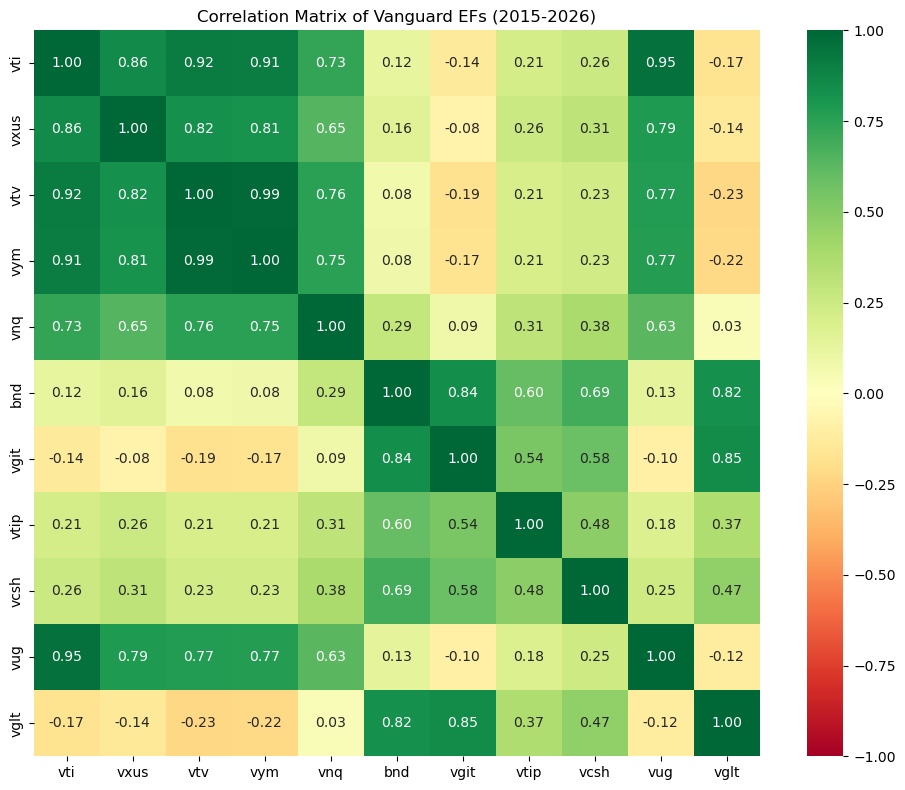

In [15]:
returns = price_data.pct_change().dropna()

corr_matrix = returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    square=True
)
plt.title("Correlation Matrix of Vanguard EFs (2015-2026)")
plt.tight_layout()
plt.show()

In [47]:
target_data = price_data[['vti', 'vxus','vtv','vnq','vgit','vtip','vglt']]
target_returns = target_data.pct_change().dropna()

mu = expected_returns.mean_historical_return(target_data, compounding=True)
S = risk_models.sample_cov(target_data)
S

,vti,vxus,vtv,vnq,vgit,vtip,vglt
vti,0.032311,0.026605,0.027317,0.026539,-0.001118,0.001014,-0.004275
vxus,0.026605,0.029897,0.023471,0.022691,-0.000637,0.001172,-0.003357
vtv,0.027317,0.023471,0.027220,0.025339,-0.001364,0.000914,-0.005310
vnq,0.026539,0.022691,0.025339,0.041211,0.000801,0.001661,0.000921
vgit,-0.001118,-0.000637,-0.001364,0.000801,0.001978,0.000634,0.005186
vtip,0.001014,0.001172,0.000914,0.001661,0.000634,0.000704,0.001334
vglt,-0.004275,-0.003357,-0.005310,0.000921,0.005186,0.001334,0.018868


In [48]:
mu

vti     0.131993
vxus    0.081566
vtv     0.114267
vnq     0.057363
vgit    0.015515
vtip    0.028606
vglt   -0.000611
dtype: float64

### 1. Startging Poin: Single Asset Variance
for a single asset i, variance is defined as
$$\sigma_i^2 = \frac{1}{T}\sum_{t=1}^{T} (r_{i,t} - \mu_i)^2$$
where
- $r_{i,t} =$ return of asset $i$ at time $t$
- $\mu_i =$ mean return of asset $i$
- $T$ = number of time periods

### 2.Extending to Two Assets: Where Diversification Appears
For a portfolio of two assets A and B with weights $w_A$ and $w_B$:
$$\sigma_p^2 = w_A^2 \sigma_A^2 + w_B^2 \sigma_B^2 + 2 w_A w_B \sigma_{AB}$$
where the covariance $\sigma_{AB}$ is :
$$\sigma_{AB} = \frac{1}{T} \sum_{t = 1}^{T} (r_{A,t} - \mu_A)(r_{B,t} - \mu_B)

The critical term is $2w_A w_B \sigma_{AB}$:


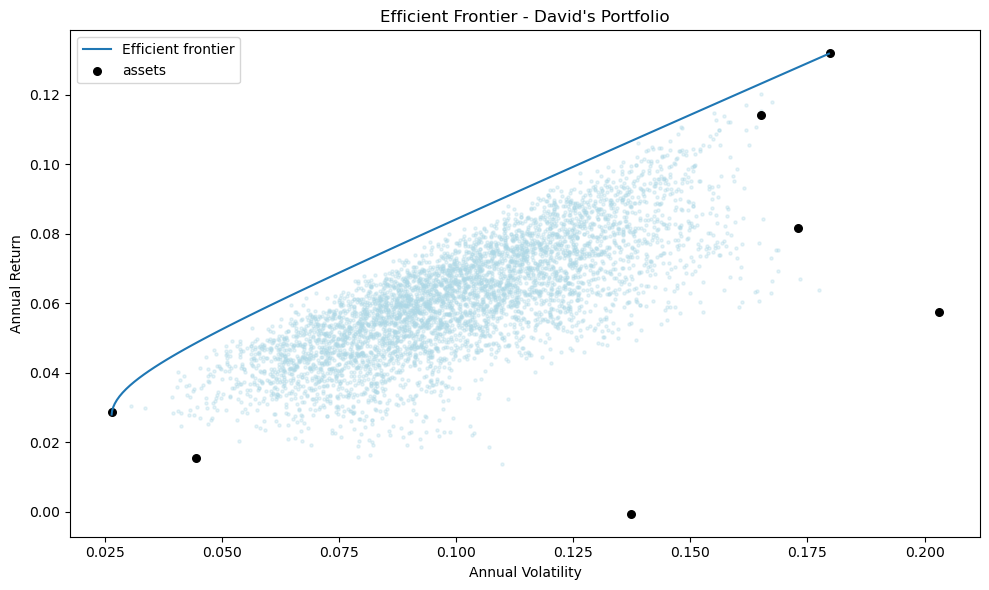

In [58]:
from pypfopt import EfficientFrontier, plotting
import matplotlib.pyplot as plt
import numpy as np

# generating efficient frontier object
ef = EfficientFrontier(mu, S)

# plotting efficient frontier
fig, ax = plt.subplots(figsize=(10, 6))

n_samples = 5000
weights_random = np.random.dirichlet(np.ones(7), n_samples)
rets, vols = [], []
for w in weights_random:
    p_ret = np.dot(w, mu)
    p_vol = np.sqrt(w @ S @ w)
    rets.append(p_ret)
    vols.append(p_vol)

ax.scatter(vols, rets, alpha=0.3, s=5, c='lightblue')

# Line of Efficient Frontier
plotting.plot_efficient_frontier(ef, ax=ax, show_assets=True)

plt.xlabel("Annual Volatility")
plt.ylabel("Annual Return")
plt.title("Efficient Frontier - David's Portfolio")
plt.tight_layout()
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/pypfopt/efficient_frontier/efficient_frontier.py:441: UserWarning: The risk_free_rate provided to portfolio_performance is different to the one used by max_sharpe. Using the previous value.
  warnings.warn(


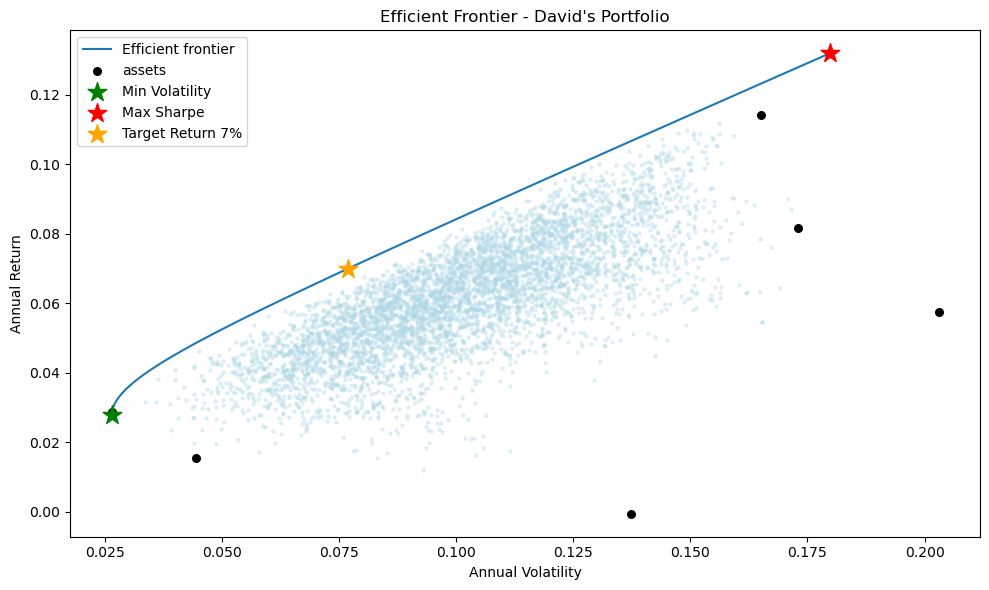

=== Min Volatility ===
OrderedDict({'vti': 0.0, 'vxus': 0.0, 'vtv': 0.0, 'vnq': 0.0, 'vgit': 0.04951, 'vtip': 0.95049, 'vglt': 0.0})
Return: 0.028, Vol: 0.026

=== Max Sharpe ===
OrderedDict({'vti': 1.0, 'vxus': 0.0, 'vtv': 0.0, 'vnq': 0.0, 'vgit': 0.0, 'vtip': 0.0, 'vglt': 0.0})
Return: 0.132, Vol: 0.180

=== Target Return 7% ===
OrderedDict({'vti': 0.40038, 'vxus': 0.0, 'vtv': 0.0, 'vnq': 0.0, 'vgit': 0.0, 'vtip': 0.59962, 'vglt': 0.0})
Return: 0.070, Vol: 0.077


In [59]:
from pypfopt import EfficientFrontier, plotting
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

n_samples = 5000
weights_random = np.random.dirichlet(np.ones(7), n_samples)
rets, vols = [], []
for w in weights_random:
    p_ret = np.dot(w, mu)
    p_vol = np.sqrt(w @ S @ w)
    rets.append(p_ret)
    vols.append(p_vol)
ax.scatter(vols, rets, alpha=0.3, s=5, c='lightblue')

ef_line = EfficientFrontier(mu, S)
plotting.plot_efficient_frontier(ef_line, ax=ax, show_assets=True)

ef1 = EfficientFrontier(mu, S)
ef1.min_volatility()
ret1, vol1, _ = ef1.portfolio_performance()
ax.scatter(vol1, ret1, marker='*', s=200, c='green', 
           zorder=5, label='Min Volatility')

ef2 = EfficientFrontier(mu, S)
ef2.max_sharpe(risk_free_rate=0.04)
ret2, vol2, _ = ef2.portfolio_performance()
ax.scatter(vol2, ret2, marker='*', s=200, c='red',
           zorder=5, label='Max Sharpe')

ef3 = EfficientFrontier(mu, S)
ef3.efficient_return(target_return=0.07)
ret3, vol3, _ = ef3.portfolio_performance()
ax.scatter(vol3, ret3, marker='*', s=200, c='orange',
           zorder=5, label='Target Return 7%')

ax.legend()
ax.set_xlabel('Annual Volatility')
ax.set_ylabel('Annual Return')
ax.set_title("Efficient Frontier - David's Portfolio")
plt.tight_layout()
plt.show()

print("=== Min Volatility ===")
print(ef1.clean_weights())
print(f"Return: {ret1:.3f}, Vol: {vol1:.3f}\n")

print("=== Max Sharpe ===")
print(ef2.clean_weights())
print(f"Return: {ret2:.3f}, Vol: {vol2:.3f}\n")

print("=== Target Return 7% ===")
print(ef3.clean_weights())
print(f"Return: {ret3:.3f}, Vol: {vol3:.3f}")

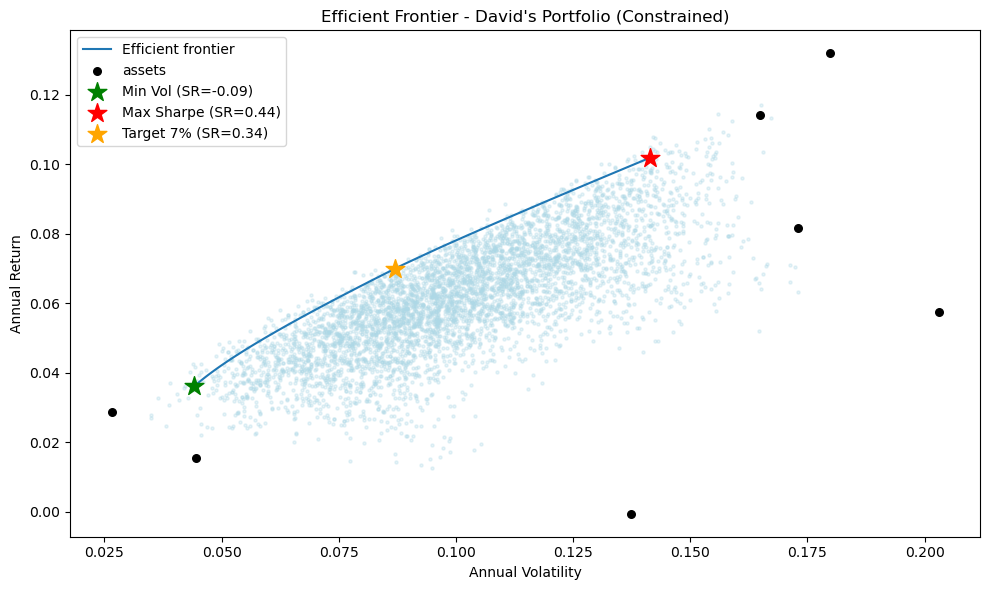

              vti  vxus   vtv   vnq   vgit  vtip  vglt
Min Vol     0.050  0.05  0.05  0.05  0.350  0.40  0.05
Max Sharpe  0.400  0.05  0.35  0.05  0.050  0.05  0.05
Target 7%   0.341  0.05  0.05  0.05  0.059  0.40  0.05

                  Return      Vol   Sharpe
Min Vol            0.036    0.044   -0.088
Max Sharpe         0.102    0.141    0.438
Target 7%          0.070    0.087    0.345


In [60]:
fig, ax = plt.subplots(figsize=(10, 6))

n_samples = 5000
weights_random = np.random.dirichlet(np.ones(7), n_samples)
rets, vols = [], []
for w in weights_random:
    p_ret = np.dot(w, mu)
    p_vol = np.sqrt(w @ S @ w)
    rets.append(p_ret)
    vols.append(p_vol)
ax.scatter(vols, rets, alpha=0.3, s=5, c='lightblue')

ef_line = EfficientFrontier(mu, S)
ef_line.add_constraint(lambda w: w <= 0.40)
ef_line.add_constraint(lambda w: w >= 0.05)
plotting.plot_efficient_frontier(ef_line, ax=ax, show_assets=True)

ef1 = EfficientFrontier(mu, S)
ef1.add_constraint(lambda w: w <= 0.40)
ef1.add_constraint(lambda w: w >= 0.05)
ef1.min_volatility()
ret1, vol1, sharpe1 = ef1.portfolio_performance(risk_free_rate=0.04)
w1 = ef1.clean_weights()

ef2 = EfficientFrontier(mu, S)
ef2.add_constraint(lambda w: w <= 0.40)
ef2.add_constraint(lambda w: w >= 0.05)
ef2.max_sharpe(risk_free_rate=0.04)
ret2, vol2, sharpe2 = ef2.portfolio_performance(risk_free_rate=0.04)
w2 = ef2.clean_weights()

ef3 = EfficientFrontier(mu, S)
ef3.add_constraint(lambda w: w <= 0.40)
ef3.add_constraint(lambda w: w >= 0.05)
ef3.efficient_return(target_return=0.07)
ret3, vol3, sharpe3 = ef3.portfolio_performance(risk_free_rate=0.04)
w3 = ef3.clean_weights()

ax.scatter(vol1, ret1, marker='*', s=200, c='green',
           zorder=5, label=f'Min Vol (SR={sharpe1:.2f})')
ax.scatter(vol2, ret2, marker='*', s=200, c='red',
           zorder=5, label=f'Max Sharpe (SR={sharpe2:.2f})')
ax.scatter(vol3, ret3, marker='*', s=200, c='orange',
           zorder=5, label=f'Target 7% (SR={sharpe3:.2f})')

ax.legend()
ax.set_xlabel('Annual Volatility')
ax.set_ylabel('Annual Return')
ax.set_title("Efficient Frontier - David's Portfolio (Constrained)")
plt.tight_layout()
plt.show()

import pandas as pd
df_weights = pd.DataFrame([w1, w2, w3], 
                           index=['Min Vol', 'Max Sharpe', 'Target 7%'])
print(df_weights.round(3))
print()
print(f"{'':15} {'Return':>8} {'Vol':>8} {'Sharpe':>8}")
print(f"{'Min Vol':15} {ret1:>8.3f} {vol1:>8.3f} {sharpe1:>8.3f}")
print(f"{'Max Sharpe':15} {ret2:>8.3f} {vol2:>8.3f} {sharpe2:>8.3f}")
print(f"{'Target 7%':15} {ret3:>8.3f} {vol3:>8.3f} {sharpe3:>8.3f}")

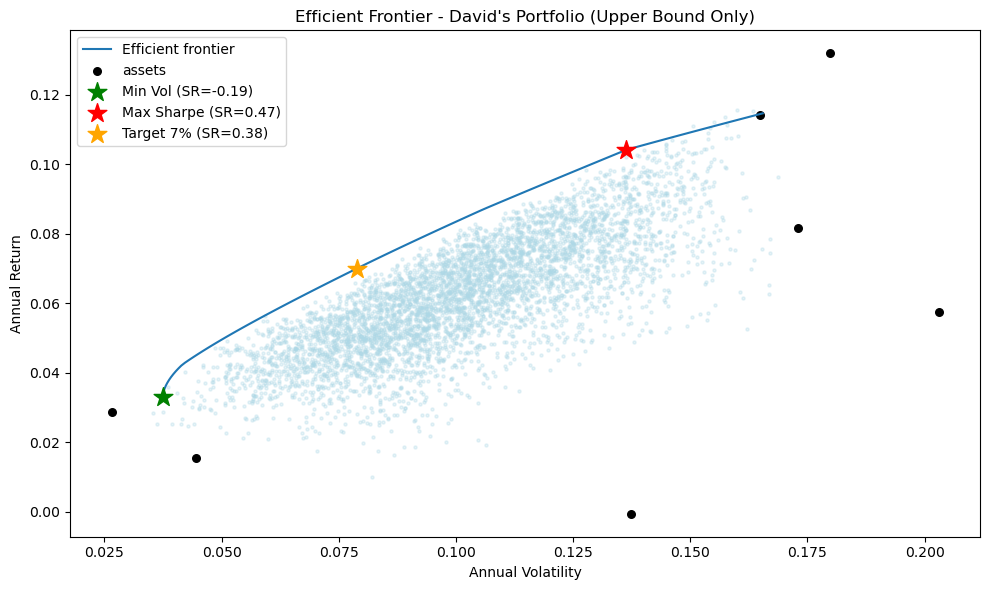

            vti  vxus    vtv  vnq   vgit  vtip   vglt
Min Vol     0.0   0.0  0.134  0.0  0.400   0.4  0.066
Max Sharpe  0.4   0.0  0.400  0.0  0.000   0.2  0.000
Target 7%   0.4   0.0  0.027  0.0  0.173   0.4  0.000

                  Return      Vol   Sharpe
Min Vol            0.033    0.037   -0.188
Max Sharpe         0.104    0.136    0.471
Target 7%          0.070    0.079    0.381


In [61]:
from pypfopt import objective_functions

fig, ax = plt.subplots(figsize=(10, 6))

# ランダムポートフォリオの雲
n_samples = 5000
weights_random = np.random.dirichlet(np.ones(7), n_samples)
rets, vols = [], []
for w in weights_random:
    p_ret = np.dot(w, mu)
    p_vol = np.sqrt(w @ S @ w)
    rets.append(p_ret)
    vols.append(p_vol)
ax.scatter(vols, rets, alpha=0.3, s=5, c='lightblue')

# Efficient Frontierのライン
ef_line = EfficientFrontier(mu, S)
ef_line.add_constraint(lambda w: w <= 0.40)  # 上限のみ
plotting.plot_efficient_frontier(ef_line, ax=ax, show_assets=True)

# ① 最小分散
ef1 = EfficientFrontier(mu, S)
ef1.add_constraint(lambda w: w <= 0.40)
ef1.min_volatility()
ret1, vol1, sharpe1 = ef1.portfolio_performance(risk_free_rate=0.04)
w1 = ef1.clean_weights()

# ② 最大シャープレシオ
ef2 = EfficientFrontier(mu, S)
ef2.add_constraint(lambda w: w <= 0.40)
ef2.max_sharpe(risk_free_rate=0.04)
ret2, vol2, sharpe2 = ef2.portfolio_performance(risk_free_rate=0.04)
w2 = ef2.clean_weights()

# ③ ターゲットリターン7%
ef3 = EfficientFrontier(mu, S)
ef3.add_constraint(lambda w: w <= 0.40)
ef3.efficient_return(target_return=0.07)
ret3, vol3, sharpe3 = ef3.portfolio_performance(risk_free_rate=0.04)
w3 = ef3.clean_weights()

# 3点をプロット
ax.scatter(vol1, ret1, marker='*', s=200, c='green',
           zorder=5, label=f'Min Vol (SR={sharpe1:.2f})')
ax.scatter(vol2, ret2, marker='*', s=200, c='red',
           zorder=5, label=f'Max Sharpe (SR={sharpe2:.2f})')
ax.scatter(vol3, ret3, marker='*', s=200, c='orange',
           zorder=5, label=f'Target 7% (SR={sharpe3:.2f})')

ax.legend()
ax.set_xlabel('Annual Volatility')
ax.set_ylabel('Annual Return')
ax.set_title("Efficient Frontier - David's Portfolio (Upper Bound Only)")
plt.tight_layout()
plt.show()

# Weights比較テーブル
import pandas as pd
df_weights = pd.DataFrame([w1, w2, w3],
                           index=['Min Vol', 'Max Sharpe', 'Target 7%'])
print(df_weights.round(3))
print()
print(f"{'':15} {'Return':>8} {'Vol':>8} {'Sharpe':>8}")
print(f"{'Min Vol':15} {ret1:>8.3f} {vol1:>8.3f} {sharpe1:>8.3f}")
print(f"{'Max Sharpe':15} {ret2:>8.3f} {vol2:>8.3f} {sharpe2:>8.3f}")
print(f"{'Target 7%':15} {ret3:>8.3f} {vol3:>8.3f} {sharpe3:>8.3f}")

In [67]:
Target_tickers = 'vti, vtv, vgit, vtip'
vti_w = 0.4
vxus_w = 0.0
vtv_w = 0.027
vnq_w = 0.0
vgit_w = 0.173
vtip_w = 0.4
vglt_w = 0.0

strat = bt.Strategy(
    'Target_7%_Strategy',
    [
        bt.algos.RunDaily(),
        bt.algos.SelectAll(),
        bt.algos.WeighSpecified(vti=vti_w, vxus=vxus_w, vtv=vtv_w,vnq=vnq_w, vgit=vgit_w, vtip=vtip_w, vglt=vglt_w),
        bt.algos.Rebalance()
    ]
)

test = bt.Backtest(strat, target_data)
res = bt.run(test)

<Axes: title={'center': 'Equity Progression'}>

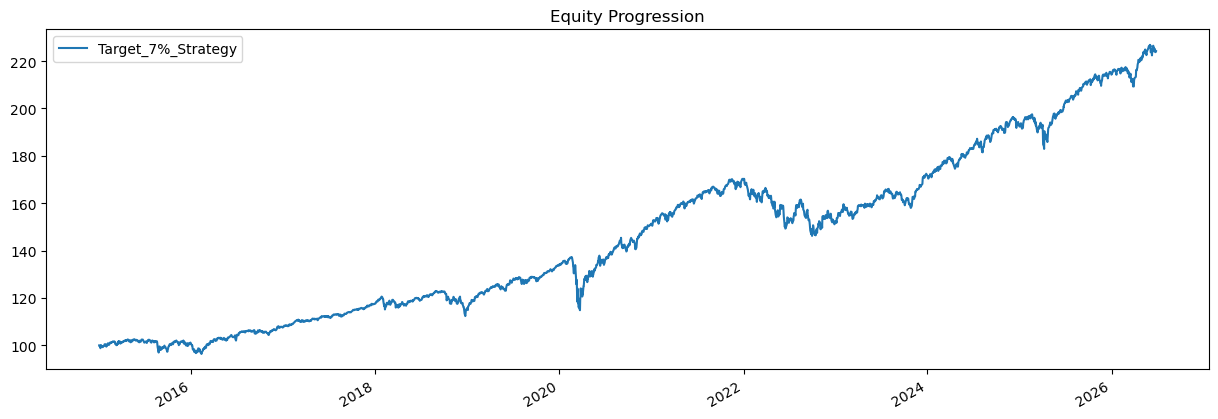

In [70]:
res.plot()

In [71]:
res.display()

Stat                 Target_7%_Strategy
-------------------  --------------------
Start                2015-01-01
End                  2026-06-26
Risk-free rate       0.00%

Total Return         124.21%
Daily Sharpe         0.93
Daily Sortino        1.32
CAGR                 7.28%
Max Drawdown         -16.33%
Calmar Ratio         0.45

MTD                  -0.96%
3m                   6.45%
6m                   4.06%
YTD                  4.64%
1Y                   11.21%
3Y (ann.)            11.52%
5Y (ann.)            6.70%
10Y (ann.)           8.20%
Since Incep. (ann.)  7.28%

Daily Sharpe         0.93
Daily Sortino        1.32
Daily Mean (ann.)    7.36%
Daily Vol (ann.)     7.88%
Daily Skew           -0.46
Daily Kurt           16.66
Best Day             4.72%
Worst Day            -5.11%

Monthly Sharpe       1.03
Monthly Sortino      1.70
Monthly Mean (ann.)  7.39%
Monthly Vol (ann.)   7.14%
Monthly Skew         -0.41
Monthly Kurt         0.83
Best Month           6.13%
Worst Month  

<Axes: title={'center': 'Equity Progression'}>

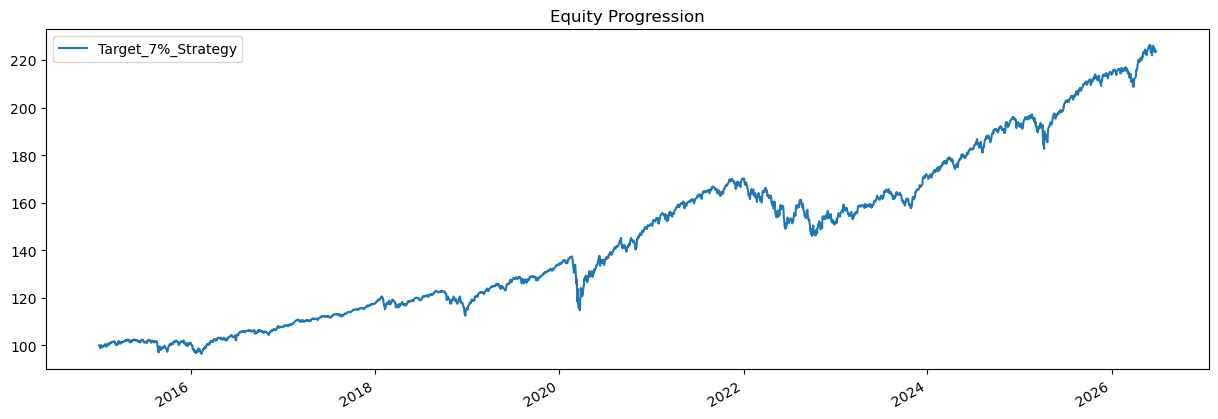

In [72]:
Target_tickers = 'vti, vtv, vgit, vtip'
vti_w = 0.4
vxus_w = 0.0
vtv_w = 0.027
vnq_w = 0.0
vgit_w = 0.173
vtip_w = 0.4
vglt_w = 0.0

strat = bt.Strategy(
    'Target_7%_Strategy',
    [
        bt.algos.RunWeekly(),
        bt.algos.SelectAll(),
        bt.algos.WeighSpecified(vti=vti_w, vxus=vxus_w, vtv=vtv_w,vnq=vnq_w, vgit=vgit_w, vtip=vtip_w, vglt=vglt_w),
        bt.algos.Rebalance()
    ]
)

test = bt.Backtest(strat, target_data)
res = bt.run(test)

res.plot()

In [73]:
res.display()

Stat                 Target_7%_Strategy
-------------------  --------------------
Start                2015-01-01
End                  2026-06-26
Risk-free rate       0.00%

Total Return         123.68%
Daily Sharpe         0.93
Daily Sortino        1.32
CAGR                 7.26%
Max Drawdown         -16.51%
Calmar Ratio         0.44

MTD                  -0.97%
3m                   6.48%
6m                   4.07%
YTD                  4.64%
1Y                   11.19%
3Y (ann.)            11.53%
5Y (ann.)            6.68%
10Y (ann.)           8.17%
Since Incep. (ann.)  7.26%

Daily Sharpe         0.93
Daily Sortino        1.32
Daily Mean (ann.)    7.34%
Daily Vol (ann.)     7.86%
Daily Skew           -0.50
Daily Kurt           16.37
Best Day             4.57%
Worst Day            -5.10%

Monthly Sharpe       1.03
Monthly Sortino      1.69
Monthly Mean (ann.)  7.37%
Monthly Vol (ann.)   7.13%
Monthly Skew         -0.42
Monthly Kurt         0.84
Best Month           5.97%
Worst Month  

<Axes: title={'center': 'Equity Progression'}>

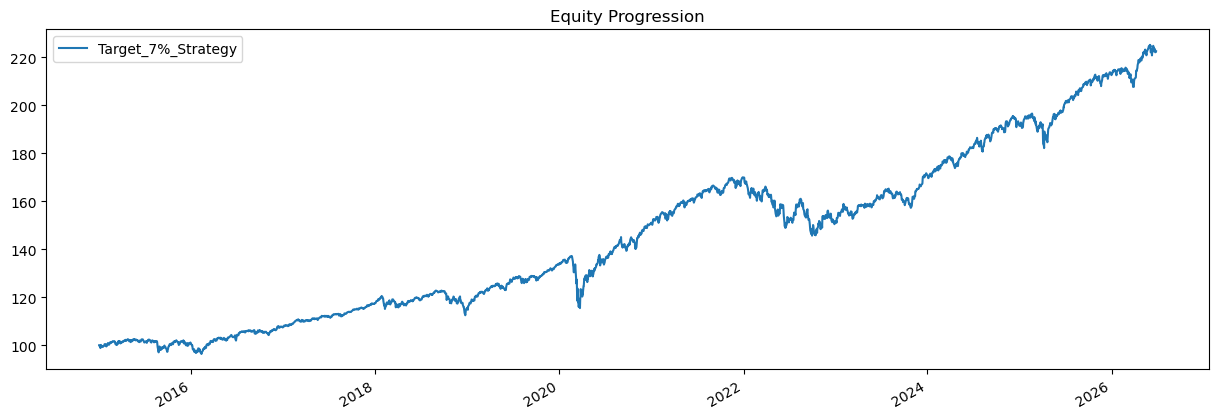

In [74]:
Target_tickers = 'vti, vtv, vgit, vtip'
vti_w = 0.4
vxus_w = 0.0
vtv_w = 0.027
vnq_w = 0.0
vgit_w = 0.173
vtip_w = 0.4
vglt_w = 0.0

strat = bt.Strategy(
    'Target_7%_Strategy',
    [
        bt.algos.RunMonthly(),
        bt.algos.SelectAll(),
        bt.algos.WeighSpecified(vti=vti_w, vxus=vxus_w, vtv=vtv_w,vnq=vnq_w, vgit=vgit_w, vtip=vtip_w, vglt=vglt_w),
        bt.algos.Rebalance()
    ]
)

test = bt.Backtest(strat, target_data)
res = bt.run(test)

res.plot()

In [75]:
res.display()

Stat                 Target_7%_Strategy
-------------------  --------------------
Start                2015-01-01
End                  2026-06-26
Risk-free rate       0.00%

Total Return         122.46%
Daily Sharpe         0.94
Daily Sortino        1.33
CAGR                 7.21%
Max Drawdown         -15.83%
Calmar Ratio         0.46

MTD                  -0.97%
3m                   6.51%
6m                   4.11%
YTD                  4.69%
1Y                   11.22%
3Y (ann.)            11.44%
5Y (ann.)            6.60%
10Y (ann.)           8.12%
Since Incep. (ann.)  7.21%

Daily Sharpe         0.94
Daily Sortino        1.33
Daily Mean (ann.)    7.28%
Daily Vol (ann.)     7.72%
Daily Skew           -0.57
Daily Kurt           13.85
Best Day             4.34%
Worst Day            -4.77%

Monthly Sharpe       1.01
Monthly Sortino      1.66
Monthly Mean (ann.)  7.32%
Monthly Vol (ann.)   7.22%
Monthly Skew         -0.39
Monthly Kurt         1.00
Best Month           6.53%
Worst Month  

<Axes: title={'center': 'Equity Progression'}>

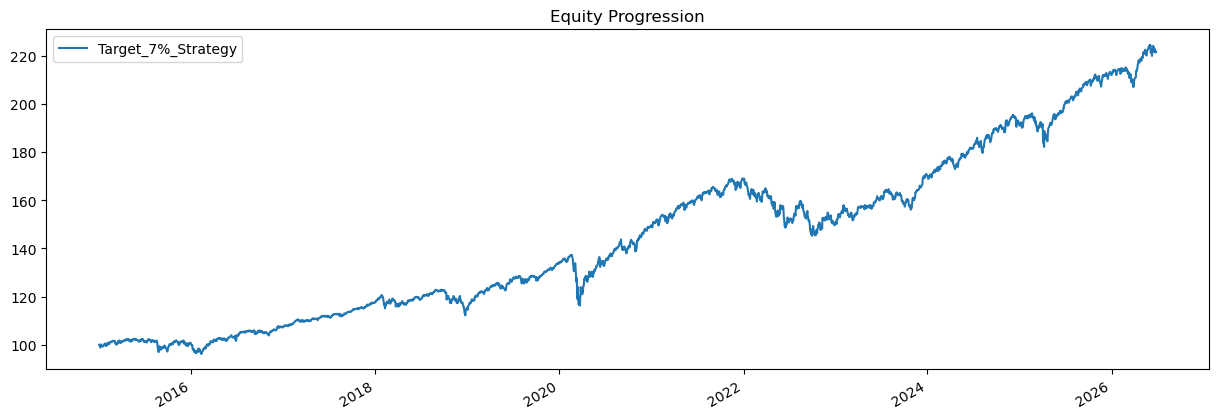

In [77]:
Target_tickers = 'vti, vtv, vgit, vtip'
vti_w = 0.4
vxus_w = 0.0
vtv_w = 0.027
vnq_w = 0.0
vgit_w = 0.173
vtip_w = 0.4
vglt_w = 0.0

strat = bt.Strategy(
    'Target_7%_Strategy',
    [
        bt.algos.RunYearly(),
        bt.algos.SelectAll(),
        bt.algos.WeighSpecified(vti=vti_w, vxus=vxus_w, vtv=vtv_w,vnq=vnq_w, vgit=vgit_w, vtip=vtip_w, vglt=vglt_w),
        bt.algos.Rebalance()
    ]
)

test = bt.Backtest(strat, target_data)
res = bt.run(test)

res.plot()

In [78]:
res.display()

Stat                 Target_7%_Strategy
-------------------  --------------------
Start                2015-01-01
End                  2026-06-26
Risk-free rate       0.00%

Total Return         121.64%
Daily Sharpe         0.95
Daily Sortino        1.33
CAGR                 7.18%
Max Drawdown         -15.33%
Calmar Ratio         0.47

MTD                  -1.02%
3m                   6.41%
6m                   3.99%
YTD                  4.60%
1Y                   11.21%
3Y (ann.)            11.51%
5Y (ann.)            6.69%
10Y (ann.)           8.12%
Since Incep. (ann.)  7.18%

Daily Sharpe         0.95
Daily Sortino        1.33
Daily Mean (ann.)    7.24%
Daily Vol (ann.)     7.61%
Daily Skew           -0.61
Daily Kurt           12.32
Best Day             4.20%
Worst Day            -4.57%

Monthly Sharpe       1.02
Monthly Sortino      1.67
Monthly Mean (ann.)  7.28%
Monthly Vol (ann.)   7.12%
Monthly Skew         -0.45
Monthly Kurt         0.62
Best Month           5.35%
Worst Month  

50/500 完了
100/500 完了
150/500 完了
200/500 完了
250/500 完了
300/500 完了
350/500 完了
400/500 完了
450/500 完了
500/500 完了


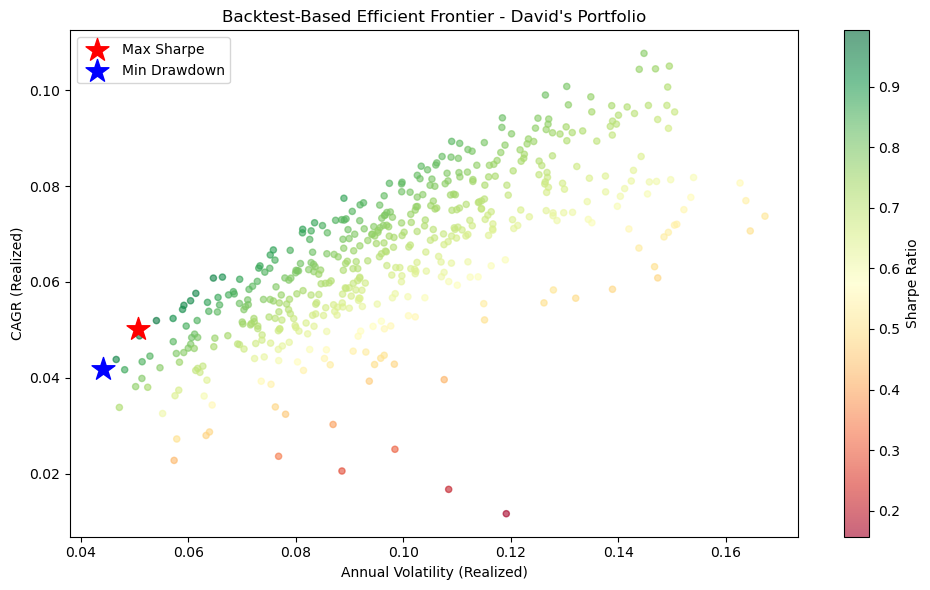


=== Max Sharpe Portfolio ===
CAGR: 0.050
Vol:  0.051
Max Drawdown: -0.130
Weights: {'vti': np.float64(0.16375254336269363), 'vxus': np.float64(0.009038652101607933), 'vtv': np.float64(0.0831730173781666), 'vnq': np.float64(0.018416263259903354), 'vgit': np.float64(0.4418865043579866), 'vtip': np.float64(0.270379275065503), 'vglt': np.float64(0.013353744474138726)}

=== Min Drawdown Portfolio ===
CAGR: 0.042
Vol:  0.044
Max Drawdown: -0.109
Weights: {'vti': np.float64(0.03293256043172688), 'vxus': np.float64(0.007293104833508551), 'vtv': np.float64(0.1061921609391848), 'vnq': np.float64(0.0604728373738572), 'vgit': np.float64(0.11576701768361897), 'vtip': np.float64(0.5939968533935042), 'vglt': np.float64(0.08334546534459951)}


In [89]:
import numpy as np
import matplotlib.pyplot as plt
import bt

# --- 結果格納リスト ---
results = []
tickers = ['vti', 'vxus', 'vtv', 'vnq', 'vgit', 'vtip', 'vglt']

n_portfolios = 500

for i in range(n_portfolios):
    # ランダムweights生成（合計1、全て非負）
    w = np.random.dirichlet(np.ones(7))
    w_dict = dict(zip(tickers, w))
    
    # ストラテジー構築
    strat = bt.Strategy(
        f'Portfolio_{i}',
        [
            bt.algos.RunQuarterly(),
            bt.algos.SelectAll(),
            bt.algos.WeighSpecified(**w_dict),
            bt.algos.Rebalance()
        ]
    )
    
    # バックテスト実行
    test = bt.Backtest(strat, target_data)
    res = bt.run(test)
    
    # 結果記録
    stats = res.stats
    cagr     = float(stats.loc['cagr'].iloc[0])
    vol      = float(stats.loc['daily_vol'].iloc[0])
    max_dd   = float(stats.loc['max_drawdown'].iloc[0])
    sharpe   = float(stats.loc['daily_sharpe'].iloc[0])
    
    results.append({
        'vol'     : vol,
        'cagr'    : cagr,
        'max_dd'  : max_dd,
        'sharpe'  : sharpe,
        'weights' : w_dict
    })
    
    # 進捗表示
    if (i+1) % 50 == 0:
        print(f'{i+1}/500 完了')

# --- DataFrameに変換 ---
results_df = pd.DataFrame(results)

# --- プロット ---
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    results_df['vol'],
    results_df['cagr'],
    c=results_df['sharpe'],   # 色でSharpeを表現
    cmap='RdYlGn',
    alpha=0.6,
    s=20
)

plt.colorbar(sc, label='Sharpe Ratio')

# 最大Sharpeの点を強調
best_idx = results_df['sharpe'].idxmax()
ax.scatter(
    results_df.loc[best_idx, 'vol'],
    results_df.loc[best_idx, 'cagr'],
    marker='*', s=300, c='red',
    zorder=5, label='Max Sharpe'
)

# 最小Drawdownの点を強調
best_dd_idx = results_df['max_dd'].idxmax()
ax.scatter(
    results_df.loc[best_dd_idx, 'vol'],
    results_df.loc[best_dd_idx, 'cagr'],
    marker='*', s=300, c='blue',
    zorder=5, label='Min Drawdown'
)

ax.set_xlabel('Annual Volatility (Realized)')
ax.set_ylabel('CAGR (Realized)')
ax.set_title("Backtest-Based Efficient Frontier - David's Portfolio")
ax.legend()
plt.tight_layout()
plt.show()

# --- ベスト結果の表示 ---
print("\n=== Max Sharpe Portfolio ===")
print(f"CAGR: {results_df.loc[best_idx, 'cagr']:.3f}")
print(f"Vol:  {results_df.loc[best_idx, 'vol']:.3f}")
print(f"Max Drawdown: {results_df.loc[best_idx, 'max_dd']:.3f}")
print(f"Weights: {results_df.loc[best_idx, 'weights']}")

print("\n=== Min Drawdown Portfolio ===")
print(f"CAGR: {results_df.loc[best_dd_idx, 'cagr']:.3f}")
print(f"Vol:  {results_df.loc[best_dd_idx, 'vol']:.3f}")
print(f"Max Drawdown: {results_df.loc[best_dd_idx, 'max_dd']:.3f}")
print(f"Weights: {results_df.loc[best_dd_idx, 'weights']}")

Stat                 Walk_Forward_Strategy    Equal_Weight    Static_Target7pct
-------------------  -----------------------  --------------  -------------------
Start                2018-04-01               2018-04-01      2018-04-01
End                  2026-06-26               2026-06-26      2026-06-26
Risk-free rate       0.00%                    0.00%           0.00%

Total Return         91.00%                   81.85%          93.41%
Daily Sharpe         0.79                     0.77            0.97
Daily Sortino        1.11                     1.07            1.37
CAGR                 8.17%                    7.53%           8.34%
Max Drawdown         -20.20%                  -20.97%         -16.33%
Calmar Ratio         0.40                     0.36            0.51

MTD                  0.20%                    0.79%           -0.96%
3m                   8.32%                    8.19%           6.45%
6m                   6.01%                    7.16%           4.06%
YTD      

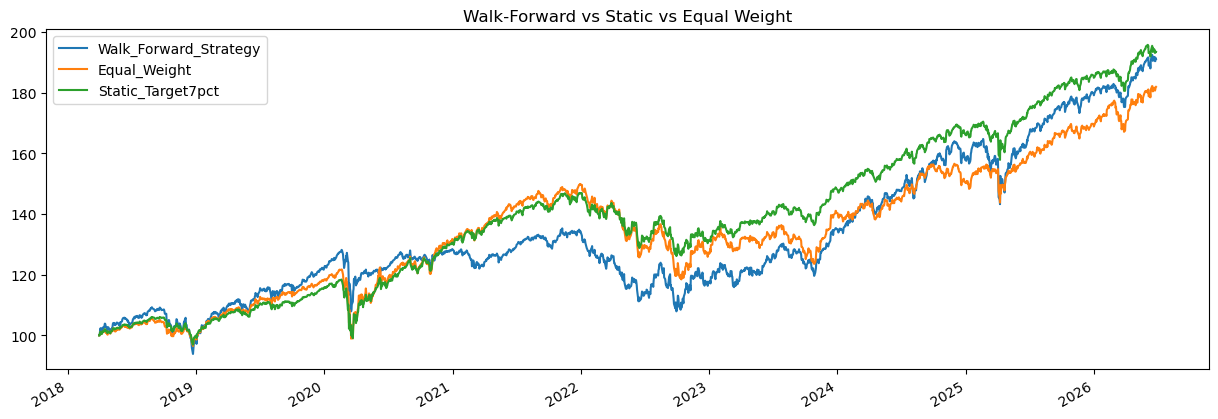

In [88]:
weights_daily = weights_df.reindex(
    target_data.index,
    method='ffill'
).dropna()

bt_data = target_data.loc[weights_daily.index]

class WeightsFromDataFrame(bt.Algo):
    """
    Algo applying dynamic weights calculated by Walk-Forward to each rebalance day
    """

    def __init__(self, weights_df):
        self.weights = weights_df

    def __call__(self, target):
        date = target.now
        if date in self.weights.index:
            target.temp['weights'] = self.weights.loc[date]
        return True

strat_wf = bt.Strategy(
    'Walk_Forward_Strategy',
    [
        bt.algos.RunQuarterly(),
        bt.algos.SelectAll(),
        WeightsFromDataFrame(weights_daily),
        bt.algos.Rebalance()
    ]
)

strat_eq = bt.Strategy(
    'Equal_Weight',
    [
        bt.algos.RunQuarterly(),
        bt.algos.SelectAll(),
        bt.algos.WeighEqually(),
        bt.algos.Rebalance()
    ]
)

strat_static = bt.Strategy(
    'Static_Target7pct',
    [
        bt.algos.RunDaily(),
        bt.algos.SelectAll(),
        bt.algos.WeighSpecified(
            vti=0.4, vxus=0.0, vtv=0.027,
            vnq=0.0, vgit=0.173, vtip=0.4, vglt=0.0
        ),
        bt.algos.Rebalance()
    ]
)

test_wf = bt.Backtest(strat_wf, bt_data)
test_eq = bt.Backtest(strat_eq, bt_data)
test_static = bt.Backtest(strat_static, bt_data)

res = bt.run(test_wf, test_eq, test_static)

res.plot(title='Walk-Forward vs Static vs Equal Weight')
res.display()

50/500 完了
100/500 完了
150/500 完了
200/500 完了
250/500 完了
300/500 完了
350/500 完了
400/500 完了
450/500 完了
500/500 完了


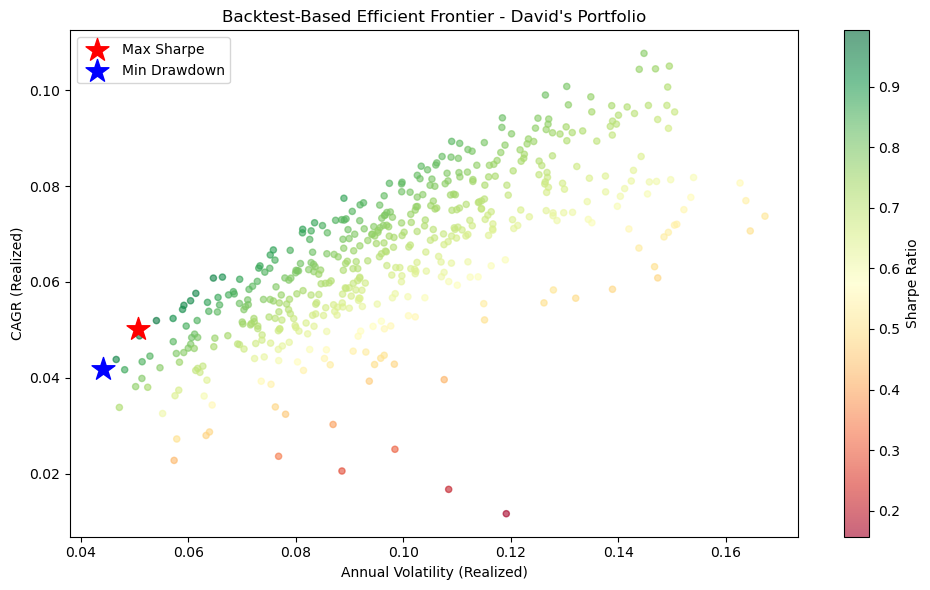


=== Max Sharpe Portfolio ===
CAGR: 0.050
Vol:  0.051
Max Drawdown: -0.130
Weights: {'vti': np.float64(0.16375254336269363), 'vxus': np.float64(0.009038652101607933), 'vtv': np.float64(0.0831730173781666), 'vnq': np.float64(0.018416263259903354), 'vgit': np.float64(0.4418865043579866), 'vtip': np.float64(0.270379275065503), 'vglt': np.float64(0.013353744474138726)}

=== Min Drawdown Portfolio ===
CAGR: 0.042
Vol:  0.044
Max Drawdown: -0.109
Weights: {'vti': np.float64(0.03293256043172688), 'vxus': np.float64(0.007293104833508551), 'vtv': np.float64(0.1061921609391848), 'vnq': np.float64(0.0604728373738572), 'vgit': np.float64(0.11576701768361897), 'vtip': np.float64(0.5939968533935042), 'vglt': np.float64(0.08334546534459951)}


In [89]:
import numpy as np
import matplotlib.pyplot as plt
import bt

# --- 結果格納リスト ---
results = []
tickers = ['vti', 'vxus', 'vtv', 'vnq', 'vgit', 'vtip', 'vglt']

n_portfolios = 500

for i in range(n_portfolios):
    # ランダムweights生成（合計1、全て非負）
    w = np.random.dirichlet(np.ones(7))
    w_dict = dict(zip(tickers, w))
    
    # ストラテジー構築
    strat = bt.Strategy(
        f'Portfolio_{i}',
        [
            bt.algos.RunQuarterly(),
            bt.algos.SelectAll(),
            bt.algos.WeighSpecified(**w_dict),
            bt.algos.Rebalance()
        ]
    )
    
    # バックテスト実行
    test = bt.Backtest(strat, target_data)
    res = bt.run(test)
    
    # 結果記録
    stats = res.stats
    cagr     = float(stats.loc['cagr'].iloc[0])
    vol      = float(stats.loc['daily_vol'].iloc[0])
    max_dd   = float(stats.loc['max_drawdown'].iloc[0])
    sharpe   = float(stats.loc['daily_sharpe'].iloc[0])
    
    results.append({
        'vol'     : vol,
        'cagr'    : cagr,
        'max_dd'  : max_dd,
        'sharpe'  : sharpe,
        'weights' : w_dict
    })
    
    # 進捗表示
    if (i+1) % 50 == 0:
        print(f'{i+1}/500 完了')

# --- DataFrameに変換 ---
results_df = pd.DataFrame(results)

# --- プロット ---
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    results_df['vol'],
    results_df['cagr'],
    c=results_df['sharpe'],   # 色でSharpeを表現
    cmap='RdYlGn',
    alpha=0.6,
    s=20
)

plt.colorbar(sc, label='Sharpe Ratio')

# 最大Sharpeの点を強調
best_idx = results_df['sharpe'].idxmax()
ax.scatter(
    results_df.loc[best_idx, 'vol'],
    results_df.loc[best_idx, 'cagr'],
    marker='*', s=300, c='red',
    zorder=5, label='Max Sharpe'
)

# 最小Drawdownの点を強調
best_dd_idx = results_df['max_dd'].idxmax()
ax.scatter(
    results_df.loc[best_dd_idx, 'vol'],
    results_df.loc[best_dd_idx, 'cagr'],
    marker='*', s=300, c='blue',
    zorder=5, label='Min Drawdown'
)

ax.set_xlabel('Annual Volatility (Realized)')
ax.set_ylabel('CAGR (Realized)')
ax.set_title("Backtest-Based Efficient Frontier - David's Portfolio")
ax.legend()
plt.tight_layout()
plt.show()

# --- ベスト結果の表示 ---
print("\n=== Max Sharpe Portfolio ===")
print(f"CAGR: {results_df.loc[best_idx, 'cagr']:.3f}")
print(f"Vol:  {results_df.loc[best_idx, 'vol']:.3f}")
print(f"Max Drawdown: {results_df.loc[best_idx, 'max_dd']:.3f}")
print(f"Weights: {results_df.loc[best_idx, 'weights']}")

print("\n=== Min Drawdown Portfolio ===")
print(f"CAGR: {results_df.loc[best_dd_idx, 'cagr']:.3f}")
print(f"Vol:  {results_df.loc[best_dd_idx, 'vol']:.3f}")
print(f"Max Drawdown: {results_df.loc[best_dd_idx, 'max_dd']:.3f}")
print(f"Weights: {results_df.loc[best_dd_idx, 'weights']}")

In [91]:
print("\n=== Max Sharpe Portfolio ===")
print(f"CAGR: {results_df.loc[best_idx, 'cagr']:.3f}")
print(f"Vol:  {results_df.loc[best_idx, 'vol']:.3f}")
print(f"Max Drawdown: {results_df.loc[best_idx, 'max_dd']:.3f}")
print(f"Weights: {results_df.loc[best_idx, 'weights']}")

print("\n=== Min Drawdown Portfolio ===")
print(f"CAGR: {results_df.loc[best_dd_idx, 'cagr']:.3f}")
print(f"Vol:  {results_df.loc[best_dd_idx, 'vol']:.3f}")
print(f"Max Drawdown: {results_df.loc[best_dd_idx, 'max_dd']:.3f}")
print(f"Weights: {results_df.loc[best_dd_idx, 'weights']}")


=== Max Sharpe Portfolio ===
CAGR: 0.050
Vol:  0.051
Max Drawdown: -0.130
Weights: {'vti': np.float64(0.16375254336269363), 'vxus': np.float64(0.009038652101607933), 'vtv': np.float64(0.0831730173781666), 'vnq': np.float64(0.018416263259903354), 'vgit': np.float64(0.4418865043579866), 'vtip': np.float64(0.270379275065503), 'vglt': np.float64(0.013353744474138726)}

=== Min Drawdown Portfolio ===
CAGR: 0.042
Vol:  0.044
Max Drawdown: -0.109
Weights: {'vti': np.float64(0.03293256043172688), 'vxus': np.float64(0.007293104833508551), 'vtv': np.float64(0.1061921609391848), 'vnq': np.float64(0.0604728373738572), 'vgit': np.float64(0.11576701768361897), 'vtip': np.float64(0.5939968533935042), 'vglt': np.float64(0.08334546534459951)}


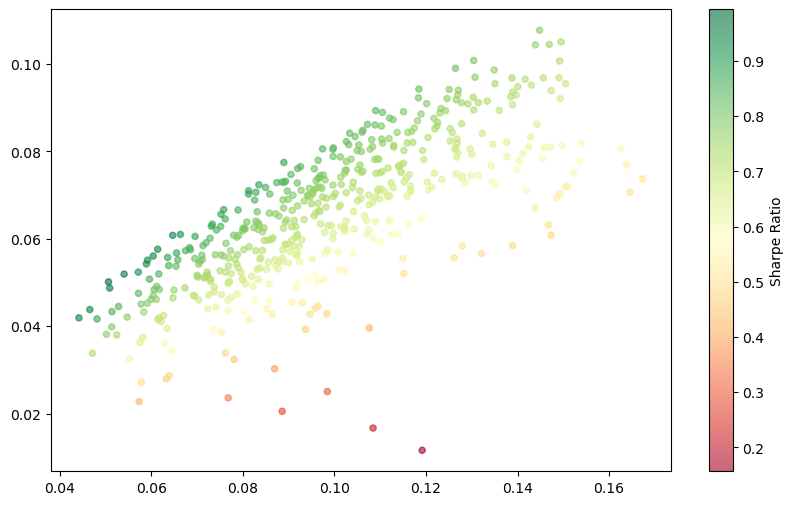

In [92]:
results_df = pd.DataFrame(results)

# --- プロット ---
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    results_df['vol'],
    results_df['cagr'],
    c=results_df['sharpe'],   # 色でSharpeを表現
    cmap='RdYlGn',
    alpha=0.6,
    s=20
)

plt.colorbar(sc, label='Sharpe Ratio')


In [93]:
# Davidの条件でフィルタリング
david_zone = results_df[
    (results_df['cagr'] >= 0.06) &    # 最低6%リターン
    (results_df['cagr'] <= 0.09) &    # 最高9%リターン
    (results_df['max_dd'] >= -0.20)   # Max Drawdown 20%以内
]

# その中でSharpe最大
best = david_zone.loc[david_zone['sharpe'].idxmax()]
print(best)
print(best['weights'])

vol                                                 0.064675
cagr                                                0.060797
max_dd                                             -0.144733
sharpe                                               0.94716
weights    {'vti': 0.24997247145852494, 'vxus': 0.0163912...
Name: 49, dtype: object
{'vti': np.float64(0.24997247145852494), 'vxus': np.float64(0.016391284275523676), 'vtv': np.float64(0.020157287759699796), 'vnq': np.float64(0.061961989850571414), 'vgit': np.float64(0.030831314078065813), 'vtip': np.float64(0.6058464257469283), 'vglt': np.float64(0.01483922683068606)}


条件を満たすポートフォリオ数: 53

=== David's Optimal Portfolio ===
CAGR        : 6.08%
Volatility  : 6.47%
Max Drawdown: -14.47%
Sharpe      : 0.947

Weights:
  VTI: 25.0%
  VXUS: 1.6%
  VTV: 2.0%
  VNQ: 6.2%
  VGIT: 3.1%
  VTIP: 60.6%
  VGLT: 1.5%


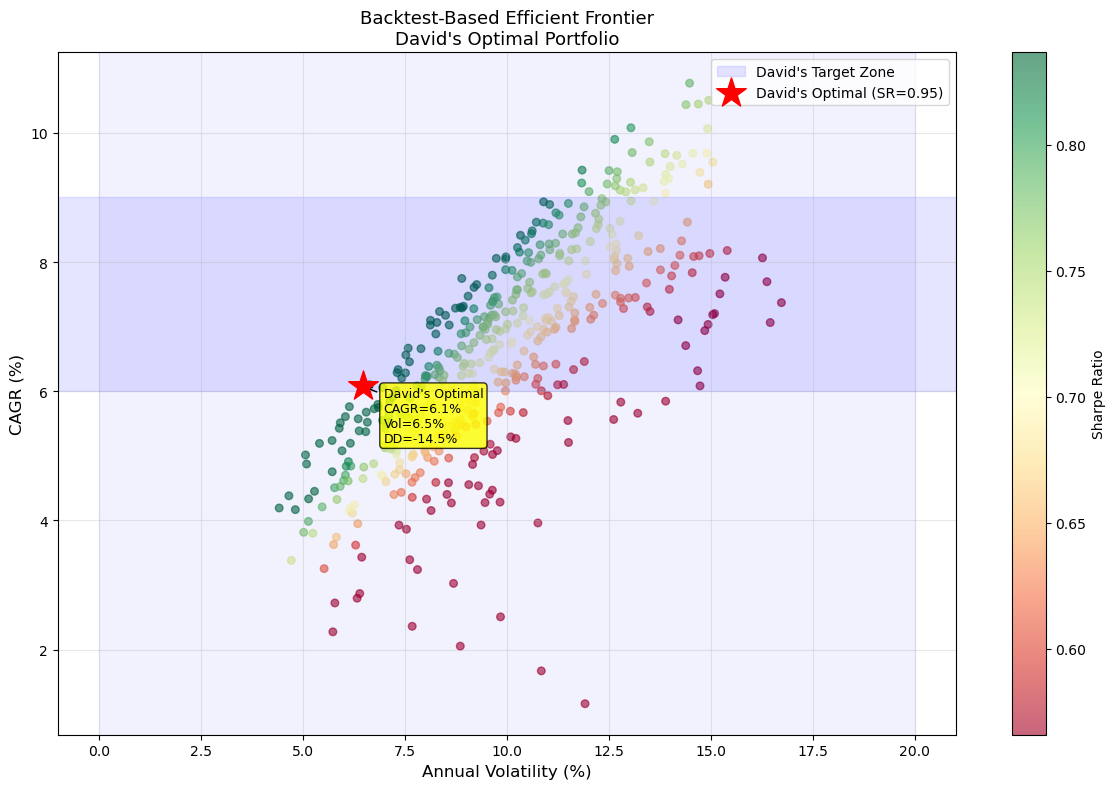

In [96]:
# --- Davidの条件でフィルタリング ---
david_zone = results_df[
    (results_df['cagr'] >= 0.06) &     # 最低6%リターン
    (results_df['cagr'] <= 0.09) &     # 最高9%リターン
    (results_df['max_dd'] >= -0.20)    # Max Drawdown 20%以内
]

print(f"条件を満たすポートフォリオ数: {len(david_zone)}")

# --- その中でSharpe最大 ---
best_idx = david_zone['sharpe'].idxmax()
best = david_zone.loc[best_idx]

print(f"\n=== David's Optimal Portfolio ===")
print(f"CAGR        : {best['cagr']*100:.2f}%")
print(f"Volatility  : {best['vol']*100:.2f}%")
print(f"Max Drawdown: {best['max_dd']*100:.2f}%")
print(f"Sharpe      : {best['sharpe']:.3f}")
print(f"\nWeights:")
for ticker, w in best['weights'].items():
    if w > 0.01:  # 1%以上のみ表示
        print(f"  {ticker.upper()}: {w*100:.1f}%")

# --- グラフに最適点を追加 ---
fig, ax = plt.subplots(figsize=(12, 8))

sc = ax.scatter(
    results_df['vol'] * 100,
    results_df['cagr'] * 100,
    c=results_df['sharpe'],
    cmap='RdYlGn',
    alpha=0.6,
    s=30,
    vmin=results_df['sharpe'].quantile(0.1),
    vmax=results_df['sharpe'].quantile(0.9)
)
plt.colorbar(sc, label='Sharpe Ratio')

# Davidゾーンをハイライト
ax.axhspan(6, 9, alpha=0.1, color='blue', label="David's Target Zone")
ax.axvspan(0, 20, alpha=0.05, color='blue')

# 最適点
ax.scatter(
    best['vol'] * 100,
    best['cagr'] * 100,
    marker='*', s=500, c='red', zorder=5,
    label=f"David's Optimal (SR={best['sharpe']:.2f})"
)
ax.annotate(
    f"David's Optimal\nCAGR={best['cagr']*100:.1f}%\nVol={best['vol']*100:.1f}%\nDD={best['max_dd']*100:.1f}%",
    xy=(best['vol']*100, best['cagr']*100),
    xytext=(15, -40), textcoords='offset points', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8),
    arrowprops=dict(arrowstyle='->', color='black')
)

ax.set_xlabel('Annual Volatility (%)', fontsize=12)
ax.set_ylabel('CAGR (%)', fontsize=12)
ax.set_title("Backtest-Based Efficient Frontier\nDavid's Optimal Portfolio", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
results_uniform = []
tickers = ['vti', 'vxus', 'vtv', 'vnq', 'vgit', 'vtip', 'vglt']

n_portfolios = 500

for i in range(n_portfolios):
    w = np.random.uniform(0, 1, 7):
    w = w / w.sum()
    w_dict = dict(zip(tickers, w))

    start